Norm of A: 1.0
Iter 1 norm est: 1.0
Iter 2 norm est: 1.0
Iter 3 norm est: 0.961001298927251
Iter 4 norm est: 0.9965506530663164
Iter 5 norm est: 0.9968614004425291
Iter 6 norm est: 0.9852655424569747
Iter 7 norm est: 0.9992591099976472
Iter 8 norm est: 0.9998594225887925
Iter 9 norm est: 0.9999818146434057
Iter 10 norm est: 0.9971458471523214
Iter 11 norm est: 0.9995898207038942
Iter 12 norm est: 0.9926086428560069
Iter 13 norm est: 0.9993137752000577
Iter 14 norm est: 0.9999478893455894
Iter 15 norm est: 0.9999950441195481
Iter 16 norm est: 0.9999958738368427
Iter 17 norm est: 0.99999910367056
Iter 18 norm est: 0.9999999058092045
Iter 19 norm est: 0.9999999924242249
Iter 20 norm est: 0.9999999937168891
Iter 21 norm est: 0.9887386458691775
Iter 22 norm est: 0.9991305207263115
Iter 23 norm est: 0.9562415720052736
Iter 24 norm est: 0.9958736241710744
Iter 25 norm est: 0.9495572672917495
Iter 26 norm est: 0.9961304196175325
Iter 27 norm est: 0.9997259621032548
Iter 28 norm est: 0.96775411

FileNotFoundError: [Errno 2] No such file or directory: '../figures/experiment2.pdf'

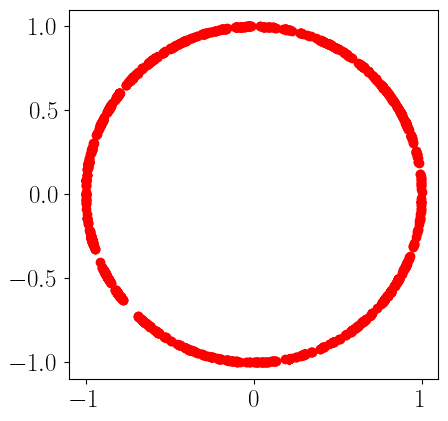

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(4242)

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 18
})


A = np.diag([1,1,0])
print(f'Norm of A: {np.linalg.norm(A,ord=2)}')

# our method

v = np.random.randn(3)
v /= np.linalg.norm(v)
Av = A@v
normAv = np.linalg.norm(Av)


plt.plot()

for k in range(5000):
    y = np.random.randn(3)
    x = y - np.sum(y*v)*v
    x /= np.linalg.norm(x)
    Ax = A@x
    normAx = np.linalg.norm(Ax)
    a = np.sum(Ax*Av)
    b = normAx**2 - normAv**2
    tau = np.sign(a)*(b/(2*np.abs(a)) + np.sqrt(b**2/(4*a**2)+1))
    v += tau*x
    v /= np.linalg.norm(v)
    Av = A@v
    nA = np.linalg.norm(Av)
    print(f'Iter {k+1} norm est: {nA}')
    if np.abs(v[2])<1e-2:
        plt.plot(v[0],v[1],'ro')


ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.savefig(f'../figures/experiment2.pdf')
plt.show()


In [3]:
# Again but now with stopping criterion
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(4242)
plt.rcParams.update({
    'text.usetex': True,
    'font.size': 18
})


A = np.diag([1,1,0])
print(f'Norm of A: {np.linalg.norm(A,ord=2)}')

# our method

v = np.random.randn(3)
v /= np.linalg.norm(v)
Av = A@v
normAv = np.linalg.norm(Av)

stopTol = 1e-2
stopCount = 0
a_s = []

for k in range(5000):
    y = np.random.randn(3)
    x = y - np.sum(y*v)*v
    x /= np.linalg.norm(x)
    Ax = A@x
    normAx = np.linalg.norm(Ax)
    a = np.sum(Ax*Av)
    a2 = a**2
    a_s.append(a)
    if a2 < stopTol**2:
        N = 20
        for l in range(N):
            y = np.random.randn(3)
            x = y - np.sum(y*v)*v
            x /= np.linalg.norm(x)
            Ax = A@x
            print(f'{l}, {np.sum(Ax*Av)}')
            a2 += np.sum(Ax*Av)**2
        if a2/N < stopTol**2:
            print('Exmpirical mean of a has become small, stop here')
            print(f'Step {k+1: 5d}. Est: {nA:2.4f}, a^2; {a2:2.2e} (step with size {tau:2.2e})')
            break
    b = normAx**2 - normAv**2
    tau = np.sign(a)*(b/(2*np.abs(a)) + np.sqrt(b**2/(4*a**2)+1))
    v += tau*x
    v /= np.linalg.norm(v)
    Av = A@v
    nA = np.linalg.norm(Av)


    
    print(f'Iter {k+1} norm est: {nA}')




Norm of A: 1.0
Iter 1 norm est: 1.0
0, -3.0531133177191805e-16
1, 2.2724877535296173e-16
2, 9.020562075079397e-17
3, -1.0408340855860843e-16
4, 1.8041124150158794e-16
5, -2.0816681711721685e-16
6, -6.245004513516506e-17
7, -4.163336342344337e-17
8, 1.3877787807814457e-17
9, 1.3877787807814457e-17
10, 1.3183898417423734e-16
11, 1.5265566588595902e-16
12, -2.237793284010081e-16
13, 2.0816681711721685e-16
14, 1.942890293094024e-16
15, 1.3877787807814457e-16
16, -1.708702623837155e-16
17, 4.163336342344337e-17
18, 3.677613769070831e-16
19, -1.491862189340054e-16
Exmpirical mean of a has become small, stop here
Step     2. Est: 1.0000, a^2; 6.27e-31 (step with size 6.41e-01)


In [ ]:
nA